# 02 Dataset Cleaning and Preprocessing

This notebook profiles, assesses, cleans, validates, and exports the merged webcam-based PM2.5 dataset.

Input: `data/interim/merged_dataset.csv`

Output: `data/processed/final_dataset.csv`

## Workflow Overview
1. Data loading  
2. Data profiling  
3. Data quality assessment  
4. Data cleaning  
5. Validation and visualization  
6. Export and summary

## Setup

In [445]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mno


## 1. Data Loading

Load the merged dataset generated from the previous dataset construction pipeline.


In [446]:
def find_project_root(start_path=None):
    """Find the nearest parent containing the project source and notebooks."""
    start = Path.cwd() if start_path is None else Path(start_path)
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root containing src/ and notebooks/."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.plot_style import COLORS, apply_thesis_style

apply_thesis_style()

INPUT_FILE = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "merged_dataset.csv"
)

# Load merged dataset
df_raw = pd.read_csv(INPUT_FILE)

print("Project root:", PROJECT_ROOT)
print("Input:", INPUT_FILE.relative_to(PROJECT_ROOT))
print(f"Rows: {len(df_raw)}")
print(f"Columns: {df_raw.shape[1]}")


Project root: /Users/qingxuan/Desktop/webcam-pm25-benchmark
Input: data/interim/merged_dataset.csv
Rows: 3862
Columns: 46


In [447]:
# Create working copy
df = df_raw.copy()

## 2. Data Profiling

Inspect dataset structure, temporal coverage, data types, and basic numerical summaries.

### 2.1 Basic structure

In [448]:
df.info()
df.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3862 entries, 0 to 3861
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   time                     3862 non-null   object 
 1   R_roi                    3862 non-null   float64
 2   G_roi                    3862 non-null   float64
 3   B_roi                    3862 non-null   float64
 4   R_std                    3862 non-null   float64
 5   G_std                    3862 non-null   float64
 6   B_std                    3862 non-null   float64
 7   S_mean                   3862 non-null   float64
 8   V_mean                   3862 non-null   float64
 9   colorfulness             3862 non-null   float64
 10  sky_brightness           3862 non-null   float64
 11  contrast                 3862 non-null   float64
 12  gray_entropy             3862 non-null   float64
 13  laplacian_variance       3862 non-null   float64
 14  mean_gradient_magnitude 

,time,R_roi,G_roi,B_roi,R_std,G_std,B_std,S_mean,V_mean,colorfulness,...,T_850,U_500,U_850,V_500,V_850,temperature_mean,wind_direction_mean,relative_humidity_mean,wind_speed_mean,wind_gust_max
0,2025-01-29 15:00:00,72.890291,102.643112,127.90583,33.593960,41.347283,45.609732,0.445059,0.501627,36.742349,...,274.20013,10.128586,0.558060,-10.743362,4.637741,11.5,100.0,67.6,1.2,3.4
1,2025-01-29 16:00:00,77.456367,108.505774,131.58280,37.263657,48.407776,57.147530,0.409142,0.517590,48.521689,...,274.14580,9.682327,0.860855,-9.707871,5.492218,10.8,91.0,70.2,2.0,3.9


### 2.2 Missing-value overview

Analyze missing values across all variables to identify incomplete observations and potential data quality issues.

In [449]:
missing_summary = (
    pd.DataFrame({
        "missing_count": df_raw.isna().sum(),
        "missing_percent": df_raw.isna().mean() * 100,
    })
    .sort_values("missing_percent", ascending=False)
)

missing_summary.head(10)

,missing_count,missing_percent
CBH,988,25.582600
wind_speed_mean,303,7.845676
D2M,60,1.553599
U10,60,1.553599
V10,60,1.553599
T2M,60,1.553599
SP,60,1.553599
TP,60,1.553599
BLH,60,1.553599
TCC,60,1.553599


<Figure size 1200x600 with 0 Axes>

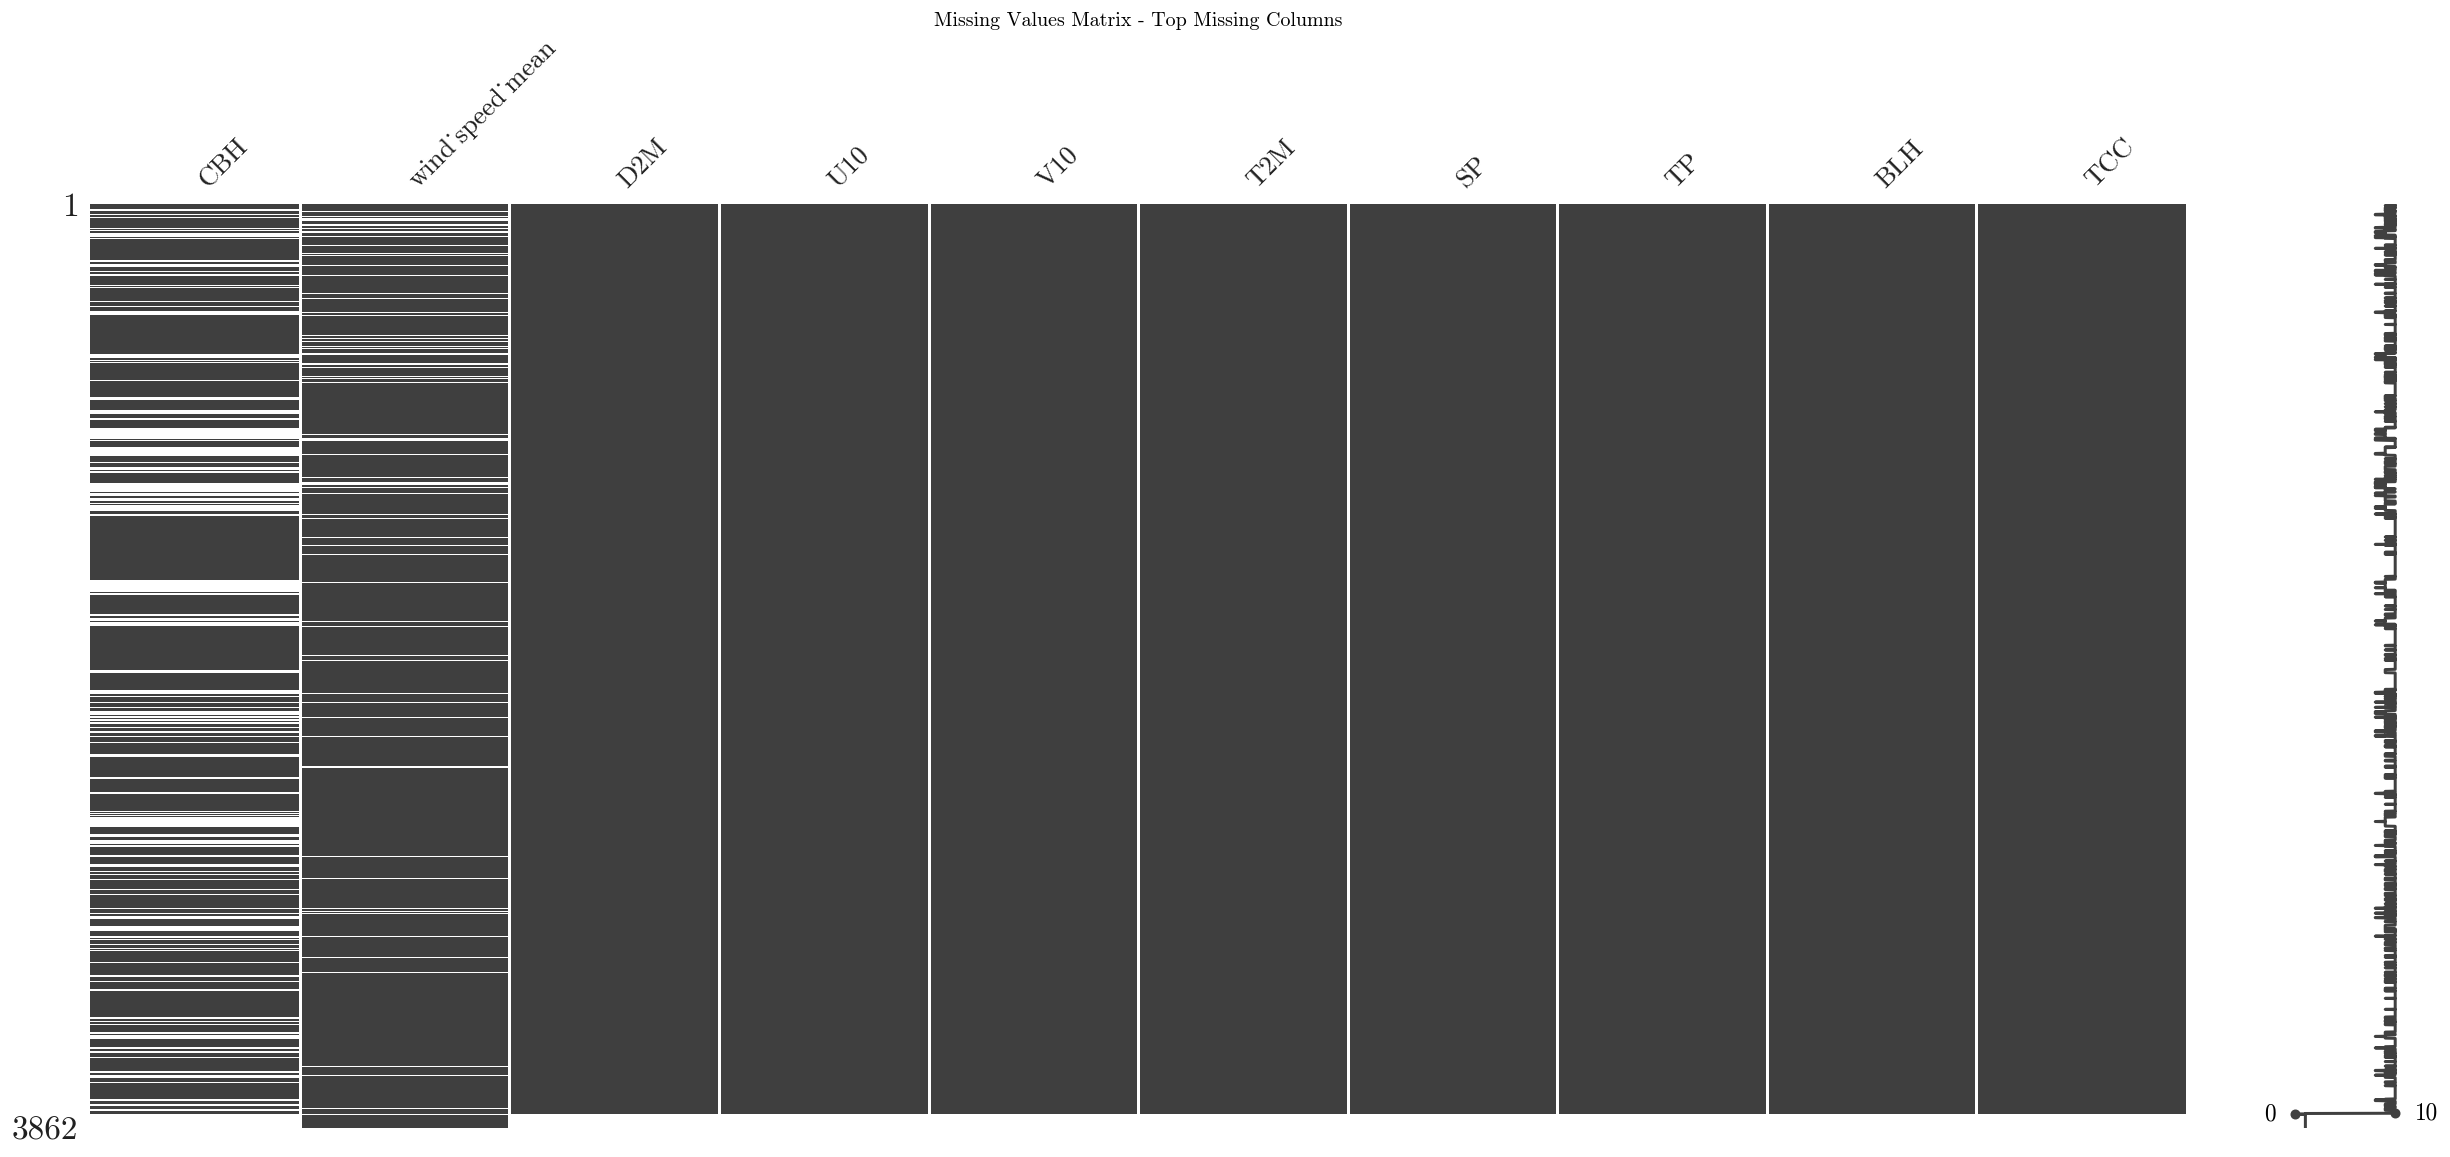

In [450]:
# Focus on the columns with the highest missing-rate values.
top_missing_cols = missing_summary.head(10).index.tolist()

plt.figure(figsize=(10, 5))

mno.matrix(df[top_missing_cols])

plt.title("Missing Values Matrix - Top Missing Columns")

plt.show()

### 2.3 Temporal coverage
Inspect temporal consistency, timestamp uniqueness, and continuity of the hourly observations.

In [451]:
# Time range
df["time"] = pd.to_datetime(df["time"])

print("Start time:", df["time"].min())
print("End time:", df["time"].max())

print(
    "Unique timestamps:",
    df["time"].nunique()
)

Start time: 2025-01-29 15:00:00
End time: 2026-08-15 21:00:00
Unique timestamps: 3862


In [452]:
#Duplicate timestamps
duplicate_count = df["time"].duplicated().sum()

print("Duplicated timestamps:", duplicate_count)


Duplicated timestamps: 0


### 2.4 Numerical profiling

Profile the numerical variables using a compact summary of scale, spread,
key distributions, and relationships with the target variable.

The aim is to identify the most informative numerical signals before
proceeding to data quality checks and cleaning.

In [453]:
# Descriptive statistics
numeric_summary = (
    df.select_dtypes(include="number")
    .describe()
    .T
)

numeric_summary

,count,mean,std,min,25%,50%,75%,max
R_roi,3862.0,102.577398,19.785944,5.422329e+01,86.767052,107.407072,117.694433,154.709561
G_roi,3862.0,128.340344,22.827193,7.330433e+01,109.417151,135.185475,145.276201,182.161686
B_roi,3862.0,153.472114,23.646804,9.817498e+01,133.777642,160.295166,171.519456,207.428411
R_std,3862.0,40.555147,7.967310,0.000000e+00,34.465289,41.007565,46.030491,77.129567
G_std,3862.0,45.188067,10.452516,0.000000e+00,34.779352,47.516317,53.011085,81.380725
B_std,3862.0,52.070821,10.990490,0.000000e+00,41.688313,54.847715,60.297377,85.995777
S_mean,3862.0,0.359192,0.044989,0.000000e+00,0.331045,0.352239,0.381700,0.550704
V_mean,3862.0,0.606478,0.091114,3.963175e-01,0.528317,0.633537,0.675887,0.813445
colorfulness,3862.0,37.351572,8.631968,0.000000e+00,31.522104,35.649052,42.123698,71.125175
sky_brightness,3862.0,0.721821,0.140614,4.048517e-01,0.628729,0.773491,0.823308,0.974245


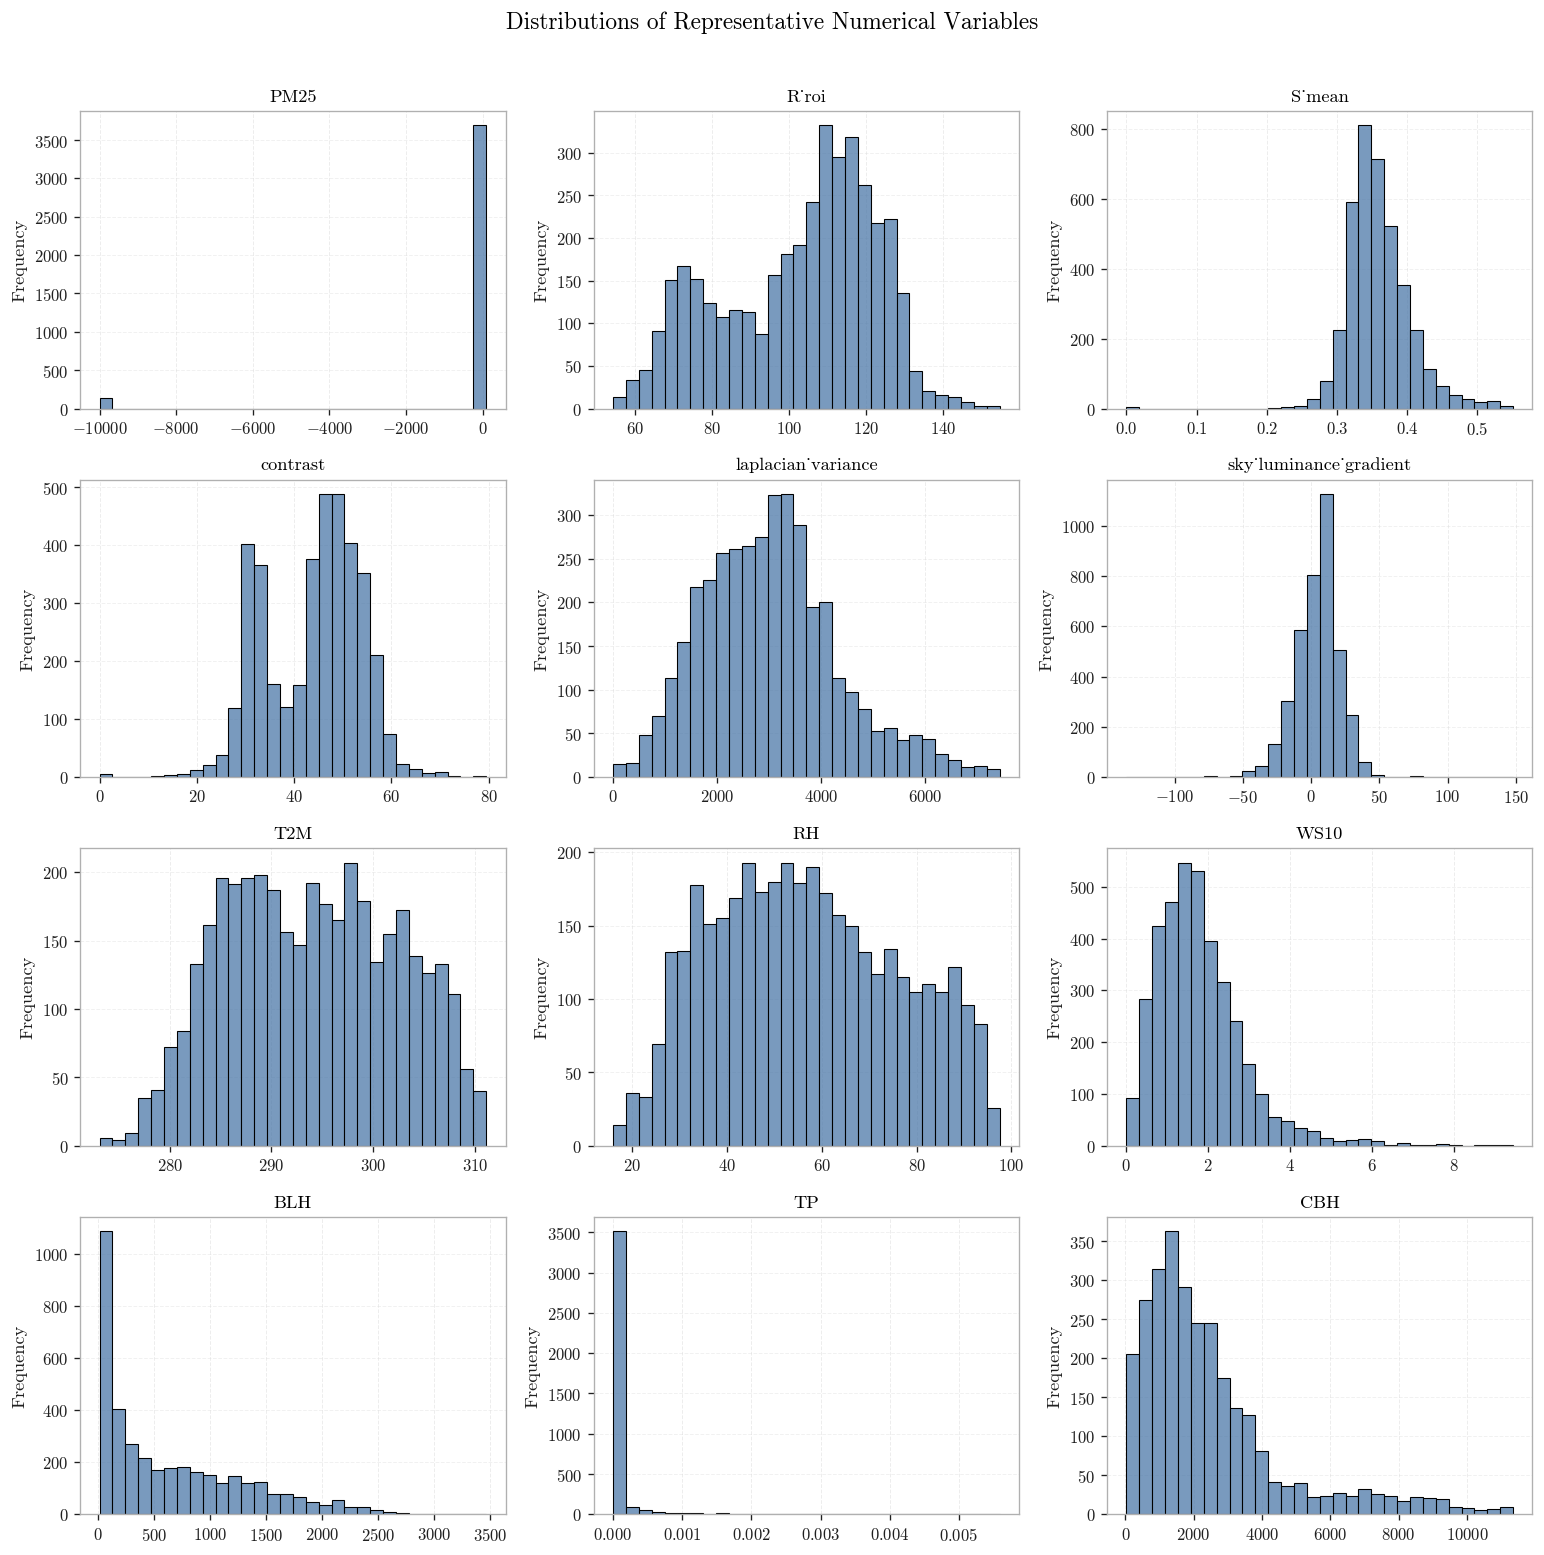

In [454]:
# Distributions of representative numerical variables

distribution_vars = [
    "PM25",
    "R_roi",
    "S_mean",
    "contrast",
    "laplacian_variance",
    "sky_luminance_gradient",
    "T2M",
    "RH",
    "WS10",
    "BLH",
    "TP",
    "CBH",
]

distribution_vars = [
    column
    for column in distribution_vars
    if column in df.columns
]

n_cols = 3
n_rows = int(
    np.ceil(len(distribution_vars) / n_cols)
)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(13, 3.2 * n_rows),
)

axes = np.atleast_1d(axes).flatten()

for ax, column in zip(
    axes,
    distribution_vars,
):
    series = df[column].dropna()

    sns.histplot(
        series,
        bins=30,
        kde=False,
        ax=ax,
    )

    ax.set_title(
        column,
        fontsize=11,
        fontweight="bold",
    )

    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.6,
        alpha=0.35,
    )

for ax in axes[len(distribution_vars):]:
    ax.remove()

fig.suptitle(
    "Distributions of Representative Numerical Variables",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()
plt.show()

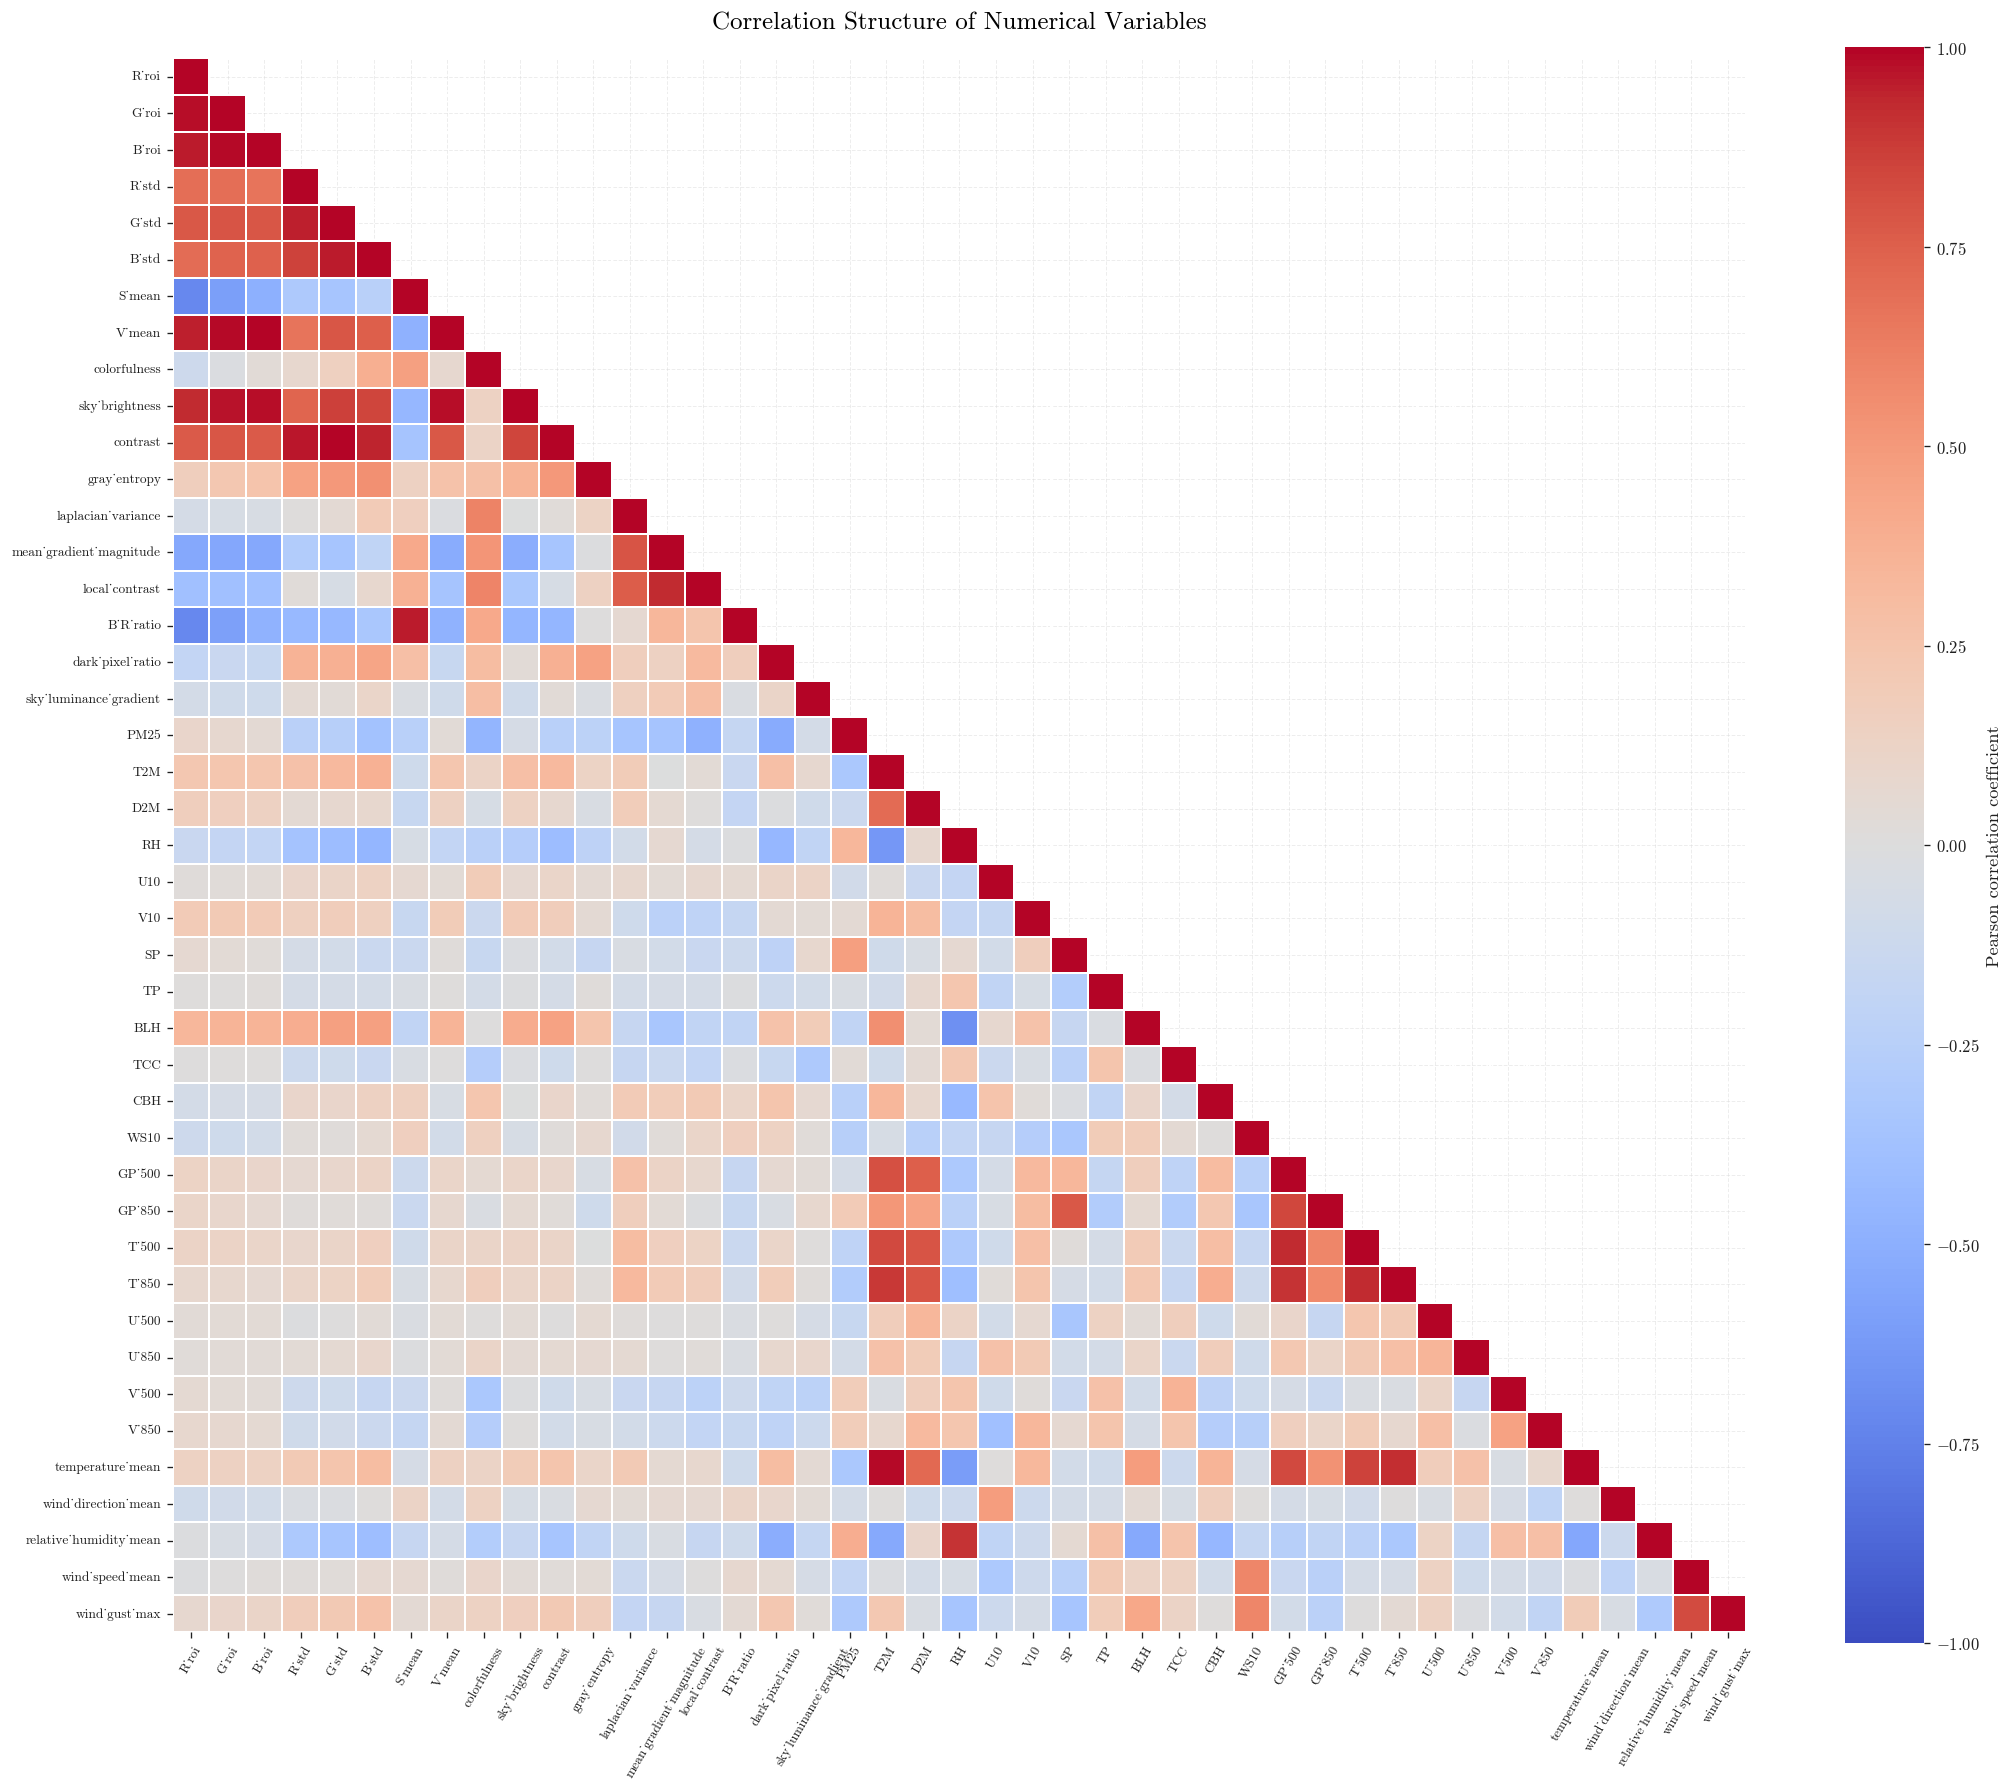

Highly correlated variable pairs (|r| ≥ 0.85): 27


,Variable 1,Variable 2,Correlation
0,B_roi,V_mean,0.999
1,G_std,contrast,0.998
2,G_roi,B_roi,0.989
3,G_roi,V_mean,0.988
4,T2M,temperature_mean,0.987
5,R_roi,G_roi,0.983
6,V_mean,sky_brightness,0.979
7,B_roi,sky_brightness,0.977
8,G_roi,sky_brightness,0.970
9,R_std,contrast,0.963


In [455]:
# Correlation structure of numerical variables

# Select all numerical variables
numeric_cols = (
    df.select_dtypes(include="number")
    .columns
    .tolist()
)

# Create a temporary copy for correlation inspection
# The original dataframe remains unchanged
corr_df = df[numeric_cols].copy()

# Replace known invalid PM2.5 code before computing correlations
if "PM25" in corr_df.columns:
    corr_df["PM25"] = corr_df["PM25"].replace(
        -9999,
        np.nan,
    )

# Compute Pearson correlation matrix
corr_matrix = corr_df.corr(
    method="pearson"
)

# Create mask for the upper triangle
upper_triangle_mask = np.triu(
    np.ones_like(
        corr_matrix,
        dtype=bool,
    ),
    k=1,
)

# Dynamically adjust figure size
n_variables = len(corr_matrix)

figure_size = max(
    12,
    n_variables * 0.42,
)

fig, ax = plt.subplots(
    figsize=(
        figure_size,
        figure_size,
    )
)

sns.heatmap(
    corr_matrix,
    mask=upper_triangle_mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.25,
    linecolor="white",
    annot=False,
    cbar_kws={
        "label": "Pearson correlation coefficient",
        "shrink": 0.75,
    },
    ax=ax,
)

ax.set_title(
    "Correlation Structure of Numerical Variables",
    fontsize=15,
    fontweight="bold",
    pad=18,
)

ax.tick_params(
    axis="x",
    labelrotation=60,
    labelsize=8,
)

ax.tick_params(
    axis="y",
    labelrotation=0,
    labelsize=8,
)

plt.tight_layout()
plt.show()


# Identify highly correlated variable pairs

correlation_threshold = 0.85

# Keep only the upper triangle to avoid duplicated pairs
upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(
            corr_matrix.shape,
            dtype=bool,
        ),
        k=1,
    )
)

high_correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_correlation_pairs.columns = [
    "Variable 1",
    "Variable 2",
    "Correlation",
]

# Filter by absolute correlation
high_correlation_pairs = (
    high_correlation_pairs[
        high_correlation_pairs[
            "Correlation"
        ].abs() >= correlation_threshold
    ]
    .assign(
        Absolute_Correlation=lambda x:
        x["Correlation"].abs()
    )
    .sort_values(
        by="Absolute_Correlation",
        ascending=False,
    )
    .drop(
        columns="Absolute_Correlation"
    )
    .reset_index(drop=True)
)

high_correlation_pairs[
    "Correlation"
] = high_correlation_pairs[
    "Correlation"
].round(3)

print(
    "Highly correlated variable pairs "
    f"(|r| ≥ {correlation_threshold}): "
    f"{len(high_correlation_pairs)}"
)

display(high_correlation_pairs)

## 3. Data Quality Assessment

Assess missing values, invalid physical values, duplicates, and potential outliers before applying cleaning rules.

### 3.1 Missing-value assessment

In [456]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0]

missing_summary.sort_values(by="missing_percent", ascending=False)

,missing_count,missing_percent
CBH,988,25.58
wind_speed_mean,303,7.85
V_850,60,1.55
V_500,60,1.55
U_850,60,1.55
U_500,60,1.55
T_850,60,1.55
T_500,60,1.55
GP_850,60,1.55
GP_500,60,1.55


### 3.2 Duplicate assessment


In [457]:
print("Duplicated rows:", df_raw.duplicated().sum())
print("Duplicated timestamps:", df_raw["time"].duplicated().sum())

Duplicated rows: 0
Duplicated timestamps: 0


### 3.3 Invalid-value assessment

In [458]:
checks = {}

# PM2.5
checks["PM25_negative"] = (df["PM25"] < 0).sum()

# Relative humidity
checks["ERA5_RH_outside_0_100"] = (
    (df["RH"] < 0) |(df["RH"] > 100)).sum()

checks["ARPA_RH_outside_0_100"] = (
    (df["relative_humidity_mean"] < 0) |(df["relative_humidity_mean"] > 100)).sum()

# Total cloud cover
checks["TCC_outside_0_1"] = (
    (df["TCC"] < 0) |(df["TCC"] > 1)).sum()

# Precipitation
checks["TP_negative"] = (df["TP"] < 0).sum()

# Wind speed
checks["wind_speed_mean_negative"] = (df["wind_speed_mean"] < 0).sum()

checks["WS10_negative"] = (df["WS10"] < 0).sum()

# Boundary-layer height and cloud-base height
checks["BLH_negative"] = ((df["BLH"] < 0).sum())

checks["CBH_negative"] = ((df["CBH"] < 0).sum())

# Wind gust
checks["wind_gust_max_negative"] = ((df["wind_gust_max"] < 0).sum())

# Wind direction
checks["wind_direction_outside_0_360"] = (
    ((df["wind_direction_mean"] < 0) |(df["wind_direction_mean"] > 360)).sum())

# RGB mean values
for col in ["R_roi", "G_roi", "B_roi"]:
    checks[f"{col}_outside_0_255"] = (((df[col] < 0) | (df[col] > 255)).sum())

# RGB standard deviations
for col in ["R_std", "G_std", "B_std"]:
    checks[f"{col}_negative"] = ((df[col] < 0).sum())

# Normalized image features
for col in ["S_mean", "V_mean", "dark_pixel_ratio"]:
    checks[f"{col}_outside_0_1"] = (((df[col] < 0) | (df[col] > 1)).sum())

# Flat ROI caused by invalid webcam images
flat_roi_mask = np.isclose(
    df[
        [
            "R_std",
            "G_std",
            "B_std",
            "contrast",
        ]
    ],
    0
).all(axis=1)

checks["invalid_flat_ROI"] = flat_roi_mask.sum()

# Convert to dataframe
invalid_summary = pd.DataFrame.from_dict(
    checks,orient="index",columns=["count"])

invalid_summary

,count
PM25_negative,140
ERA5_RH_outside_0_100,0
ARPA_RH_outside_0_100,0
TCC_outside_0_1,0
TP_negative,0
wind_speed_mean_negative,0
WS10_negative,0
BLH_negative,0
CBH_negative,0
wind_gust_max_negative,0


### 3.4 Outlier assessment

In [459]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

outlier_rows = []

for col in numeric_cols:
    series = df[col].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_mask = (
        (df[col] < lower) |
        (df[col] > upper)
    )

    count = int(outlier_mask.sum())
    percent = round(count / df[col].notna().sum() * 100, 2)

    outlier_rows.append({
        "column": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "iqr_outlier_count": count,
        "iqr_outlier_percent": percent
    })

outlier_summary = (
    pd.DataFrame(outlier_rows)
    .sort_values(
        "iqr_outlier_count",
        ascending=False
    )
    .reset_index(drop=True)
)

outlier_summary.head(15)

,column,lower_bound,upper_bound,iqr_outlier_count,iqr_outlier_percent
0,TP,-0.000007,0.000012,802,21.09
1,PM25,-9.035795,33.409135,437,11.41
2,dark_pixel_ratio,0.020294,0.168194,307,7.95
3,V_850,-5.601738,6.458443,235,6.18
4,CBH,-2042.730788,6266.431313,233,8.11
5,B_R_ratio,1.265218,1.739143,166,4.30
6,U_850,-6.383119,6.107038,151,3.97
7,S_mean,0.255062,0.457683,136,3.52
8,SP,98795.871250,101364.981250,133,3.50
9,WS10,-0.785401,4.186961,129,3.39


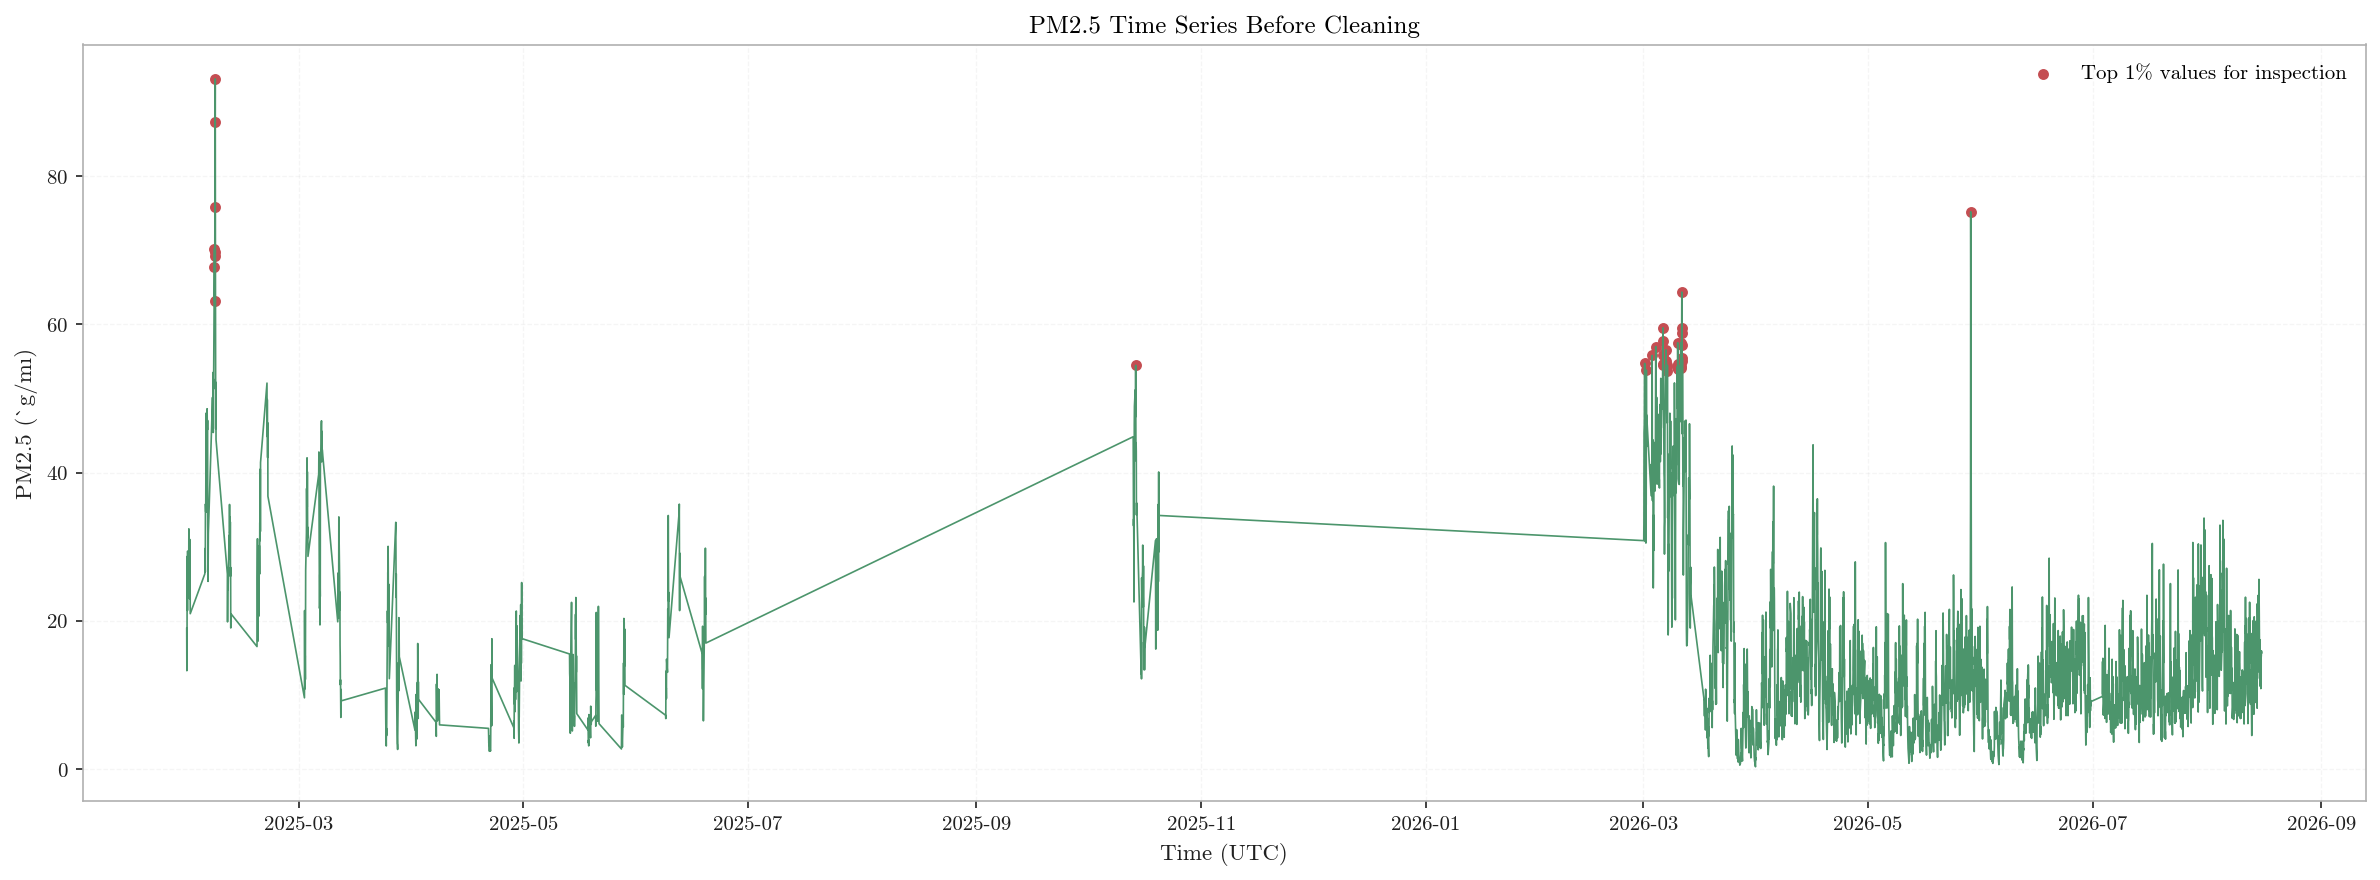

In [460]:
# Visual inspection of valid PM2.5 values across the merged analysis timeline
pm25_time_series = (
    df[["time", "PM25"]].copy()
    .replace({"PM25": {-9999: np.nan}})
    .dropna(subset=["time", "PM25"])
    .sort_values("time")
)

pm25_high_threshold = pm25_time_series["PM25"].quantile(0.99)
pm25_high_mask = pm25_time_series["PM25"] >= pm25_high_threshold

fig, ax = plt.subplots(figsize=(16, 6), dpi=150)

ax.plot(
    pm25_time_series["time"],
    pm25_time_series["PM25"],
    color=COLORS["secondary"],
    linewidth=0.8,
)

ax.scatter(
    pm25_time_series.loc[pm25_high_mask, "time"],
    pm25_time_series.loc[pm25_high_mask, "PM25"],
    color=COLORS["high"],
    s=18,
    label="Top 1% values for inspection",
)

ax.set_title("PM2.5 Time Series Before Cleaning")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()


### 3.5 Temporal consistency assessment

In [461]:
# Expected timestamps: every hour from 03:00 to 22:00
expected_range = pd.date_range(
    start=df["time"].min().normalize(),
    end=df["time"].max().normalize() + pd.Timedelta(hours=22),
    freq="h"
)

expected_range = expected_range[
    (expected_range.hour >= 3) &(expected_range.hour <= 22)]

missing_times = expected_range.difference(
    pd.DatetimeIndex(df["time"]))

print("Expected timestamps:", len(expected_range))
print("Observed timestamps:", df["time"].nunique())
print("Missing timestamps:", len(missing_times))


Expected timestamps: 11280
Observed timestamps: 3862
Missing timestamps: 7574


## 4. Data Cleaning

Apply data type conversion, missing-value handling, invalid-value correction, deduplication, and feature transformation.

### 4.1 Data Transformation and Standardization

Standardize the dataset structure by converting time fields and sorting observations chronologically.

In [462]:
# Convert time to datetime
df["time"] = pd.to_datetime(
    df["time"],
    errors="coerce"
)

# Remove invalid timestamps
invalid_time_count = df["time"].isna().sum()

df = (
    df.dropna(subset=["time"])
    .sort_values("time")
    .reset_index(drop=True)
)

print("Invalid timestamps removed:", invalid_time_count)
print("Time range:", df["time"].min(), "to", df["time"].max())
print("Rows:", len(df))

Invalid timestamps removed: 0
Time range: 2025-01-29 15:00:00 to 2026-08-15 21:00:00
Rows: 3862


In [463]:
# Replace textual missing-value markers
df = df.replace(
    ["<NA>", "NA", "N/A", ""],
    pd.NA
)

# Convert modeling variables to numeric
non_numeric_columns = [
    "time",
    "image_path",
    "Unit",
]

numeric_columns = [
    col for col in df.columns
    if col not in non_numeric_columns
]

df[numeric_columns] = df[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

print("Numeric conversion completed.")
print(
    "Missing values after conversion:",
    df.isna().sum().sum()
)

Numeric conversion completed.
Missing values after conversion: 2448


### 4.2 Missing-Value Handling

Handle missing values using variable-specific interpolation and filling strategies.

In [464]:
missing_before = df.isna().sum().sum()

# 1. Remove rows with missing PM2.5 target values
rows_before = len(df)
df = df.dropna(subset=["PM25"]).reset_index(drop=True)
print("Rows removed due to missing PM25:",rows_before - len(df))


# 2. Remove CBH because of its high missing rate
df = df.drop(
    columns=["CBH"],errors="ignore")
print("Dropped column: CBH")


# 3. Interpolate temperature and wind speed
continuous_columns = ["temperature_mean","wind_speed_mean",]

for col in continuous_columns:
    # Interpolate short gaps
    df[col] = df[col].interpolate(method="linear",limit=2,limit_area="inside")

    # Fill remaining gaps with the median
    df[col] = df[col].fillna(df[col].median())


# 4. Circular interpolation for wind direction
direction_rad = np.radians(df["wind_direction_mean"])

direction_sin = pd.Series(
    np.sin(direction_rad),index=df.index).interpolate(limit_direction="both")

direction_cos = pd.Series(
    np.cos(direction_rad),index=df.index).interpolate(limit_direction="both")

df["wind_direction_mean"] = (
    np.degrees(np.arctan2(direction_sin, direction_cos)) % 360)


# 5. Check remaining missing values
missing_after = df.isna().sum()
remaining_missing = missing_after[missing_after > 0]

print("Missing values before:", missing_before)
print("Remaining missing values:", int(remaining_missing.sum()))

if remaining_missing.empty:
    print("No missing values remain.")
else:
    display(remaining_missing)

Rows removed due to missing PM25: 31
Dropped column: CBH
Missing values before: 2448
Remaining missing values: 1008


T2M       56
D2M       56
RH        56
U10       56
V10       56
SP        56
TP        56
BLH       56
TCC       56
WS10      56
GP_500    56
GP_850    56
T_500     56
T_850     56
U_500     56
U_850     56
V_500     56
V_850     56
dtype: int64

### 4.3 Invalid-Value Correction

Remove observations containing physically invalid or unrealistic values.

In [465]:
# Identify physically invalid rows
invalid_mask = (
    (df["PM25"] < 0) |
    (~df["RH"].between(0, 100)) |
    (~df["relative_humidity_mean"].between(0, 100)) |
    (~df["TCC"].between(0, 1)) |
    (df["TP"] < 0) |
    (df["wind_speed_mean"] < 0) |
    (df["WS10"] < 0) |
    (df["BLH"] < 0) |
    (df["wind_gust_max"] < 0) |
    (~df["wind_direction_mean"].between(0, 360))
)

# Detect invalid uniform-gray ROI images
flat_roi_mask = np.isclose(
    df[
        [
            "R_std",
            "G_std",
            "B_std",
            "contrast",
        ]
    ],
    0
).all(axis=1)

invalid_mask |= flat_roi_mask

# RGB mean values
for col in ["R_roi", "G_roi", "B_roi"]:invalid_mask |= ~df[col].between(0, 255)

# RGB standard deviations
for col in ["R_std", "G_std", "B_std"]:invalid_mask |= df[col] < 0

# Normalized image features
for col in ["S_mean", "V_mean", "dark_pixel_ratio"]:invalid_mask |= ~df[col].between(0, 1)

# CBH may already have been removed in Section 4.2
if "CBH" in df.columns:invalid_mask |= df["CBH"] < 0

# Remove invalid rows
rows_before = len(df)
df = df[~invalid_mask].reset_index(drop=True)

print("Rows before invalid-value filtering:", rows_before)
print("Invalid rows identified:", int(invalid_mask.sum()))
print("Rows after invalid-value filtering:", len(df))
print("Rows removed:", rows_before - len(df))

Rows before invalid-value filtering: 3831
Invalid rows identified: 201
Rows after invalid-value filtering: 3630
Rows removed: 201


### 4.4 Documented Anomalous-Interval Exclusion

Exclude the specific time interval for which manual inspection confirmed anomalous observations. The interval is documented explicitly and is not inferred automatically from the PM2.5 magnitude.

In [466]:
# Interval excluded after manual inspection of the corresponding observations
excluded_interval_start = pd.Timestamp("2026-05-28 17:00:00")
excluded_interval_end = pd.Timestamp("2026-05-28 21:00:00")

excluded_interval_mask = df["time"].between(
    excluded_interval_start,
    excluded_interval_end,
    inclusive="both",
)

excluded_rows = df.loc[
    excluded_interval_mask,
    ["time", "PM25", "image_path"],
].copy()

df = df.loc[~excluded_interval_mask].reset_index(drop=True)

print("Excluded interval:", excluded_interval_start, "to", excluded_interval_end)
print("Rows removed after manual inspection:", len(excluded_rows))
display(excluded_rows)

Excluded interval: 2026-05-28 17:00:00 to 2026-05-28 21:00:00
Rows removed after manual inspection: 5


,time,PM25,image_path
2188,2026-05-28 17:00:00,9.775008,data/raw/images/20260528-1900.jpg
2189,2026-05-28 18:00:00,21.225307,data/raw/images/20260528-2000.jpg
2190,2026-05-28 19:00:00,30.737974,data/raw/images/20260528-2100.jpg
2191,2026-05-28 20:00:00,36.180130,data/raw/images/20260528-2200.jpg
2192,2026-05-28 21:00:00,75.183060,data/raw/images/20260528-2300.jpg


### 4.5 Remove Non-Modeling Columns

Remove columns that are not useful for numerical modeling.

In [467]:
columns_to_drop = [
    "image_path",
    "Unit",
]

columns_to_drop = [
    col for col in columns_to_drop
    if col in df.columns
]

df = df.drop(columns=columns_to_drop)

print("Dropped columns:", columns_to_drop)

print("Shape after dropping columns:", df.shape)

Dropped columns: ['image_path', 'Unit']
Shape after dropping columns: (3625, 43)


### 4.6 Numeric Conversion

Convert numeric-like variables to proper numeric formats for analysis and modeling.

In [468]:
# Check that all modeling columns are numeric
non_numeric_columns = (
    df.drop(columns=["time"])
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

if non_numeric_columns:
    print("Non-numeric columns found:", non_numeric_columns)
else:
    print("All modeling columns are numeric.")

print("Remaining missing values:", df.isna().sum().sum())

All modeling columns are numeric.
Remaining missing values: 0


### 4.7 Duplicate Removal

Check and remove duplicated timestamp observations.

In [469]:
rows_before = len(df)

df = df.drop_duplicates(subset="time").reset_index(drop=True)

rows_after = len(df)

print("Duplicate timestamps removed:",rows_before - rows_after)

print("Rows after duplicate removal:", rows_after)

Duplicate timestamps removed: 0
Rows after duplicate removal: 3625


### 4.8 Temporal and Wind-Direction Feature Engineering

Generate additional temporal and circular features to better represent periodic environmental patterns.

In [470]:
# These features are useful because air pollution and illumination have daily cycles.
# Basic temporal features
df["hour"] = df["time"].dt.hour
df["day"] = df["time"].dt.day
df["weekday"] = df["time"].dt.weekday
df["month"] = df["time"].dt.month

# Hourly cycle
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Weekly cycle
df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

# Seasonal cycle
df["month_sin"] = np.sin(2 * np.pi * (df["month"] - 1) / 12)
df["month_cos"] = np.cos(2 * np.pi * (df["month"] - 1) / 12)

# Weekend indicator
df["is_weekend"] = (df["weekday"] >= 5).astype(int)

# Approximate daytime indicator
df["is_daytime"] = (
    (df["hour"] >= 6) &(df["hour"] <= 18)).astype(int)

temporal_features = [
    "time",
    "hour",
    "day",
    "weekday",
    "month",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos",
    "is_weekend",
    "is_daytime",
]

df[temporal_features].head()

,time,hour,day,weekday,month,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos,is_weekend,is_daytime
0,2025-01-29 15:00:00,15,29,2,1,-0.707107,-7.071068e-01,0.974928,-0.222521,0.0,1.0,0,1
1,2025-01-29 16:00:00,16,29,2,1,-0.866025,-5.000000e-01,0.974928,-0.222521,0.0,1.0,0,1
2,2025-01-29 17:00:00,17,29,2,1,-0.965926,-2.588190e-01,0.974928,-0.222521,0.0,1.0,0,1
3,2025-01-29 18:00:00,18,29,2,1,-1.000000,-1.836970e-16,0.974928,-0.222521,0.0,1.0,0,1
4,2025-01-29 19:00:00,19,29,2,1,-0.965926,2.588190e-01,0.974928,-0.222521,0.0,1.0,0,0


In [471]:
# Convert wind direction to circular features

df["wind_dir_sin"] = np.sin(
    np.radians(df["wind_direction_mean"]))

df["wind_dir_cos"] = np.cos(
    np.radians(df["wind_direction_mean"]))

df[[ "wind_direction_mean","wind_dir_sin", "wind_dir_cos"]].head()

,wind_direction_mean,wind_dir_sin,wind_dir_cos
0,100.0,0.984808,-0.173648
1,91.0,0.999848,-0.017452
2,107.0,0.956305,-0.292372
3,86.0,0.997564,0.069756
4,8.0,0.139173,0.990268


## 5. Validation & Visualization

Validate the cleaned dataset and visualize key variables after preprocessing.

### 5.1 Final dataset validation

In [472]:
numeric_df = df.select_dtypes(include=np.number)

print("Final shape:", df.shape)
print("Final missing values:", df.isna().sum().sum())
print("Infinite values:", np.isinf(numeric_df).sum().sum())
print("Duplicated timestamps:", df["time"].duplicated().sum())
print("Time sorted:", df["time"].is_monotonic_increasing)
print("Negative PM2.5 values:", (df["PM25"] < 0).sum())

df.head()

Final shape: (3625, 57)
Final missing values: 0
Infinite values: 0
Duplicated timestamps: 0
Time sorted: True
Negative PM2.5 values: 0


,time,R_roi,G_roi,B_roi,R_std,G_std,B_std,S_mean,V_mean,colorfulness,...,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos,is_weekend,is_daytime,wind_dir_sin,wind_dir_cos
0,2025-01-29 15:00:00,72.890291,102.643112,127.905830,33.593960,41.347283,45.609732,0.445059,0.501627,36.742349,...,-0.707107,-7.071068e-01,0.974928,-0.222521,0.0,1.0,0,1,0.984808,-0.173648
1,2025-01-29 16:00:00,77.456367,108.505774,131.582800,37.263657,48.407776,57.147530,0.409142,0.517590,48.521689,...,-0.866025,-5.000000e-01,0.974928,-0.222521,0.0,1.0,0,1,0.999848,-0.017452
2,2025-01-29 17:00:00,61.865319,81.209939,99.889218,36.117171,39.679788,46.476770,0.439677,0.409517,45.040358,...,-0.965926,-2.588190e-01,0.974928,-0.222521,0.0,1.0,0,1,0.956305,-0.292372
3,2025-01-29 18:00:00,76.285973,96.945933,117.473485,40.910550,39.854581,42.496365,0.384557,0.467538,33.898834,...,-1.000000,-1.836970e-16,0.974928,-0.222521,0.0,1.0,0,1,0.997564,0.069756
4,2025-01-29 19:00:00,82.091906,102.342810,122.670874,35.199885,35.962358,41.029133,0.349021,0.485637,31.291664,...,-0.965926,2.588190e-01,0.974928,-0.222521,0.0,1.0,0,0,0.139173,0.990268


### 5.2 Boxplots After Cleaning

Visualize the distributions of representative variables after cleaning.
Points outside the boxplot whiskers are treated as potential statistical
outliers rather than automatically removed, because extreme pollution and
meteorological observations may still be physically valid.

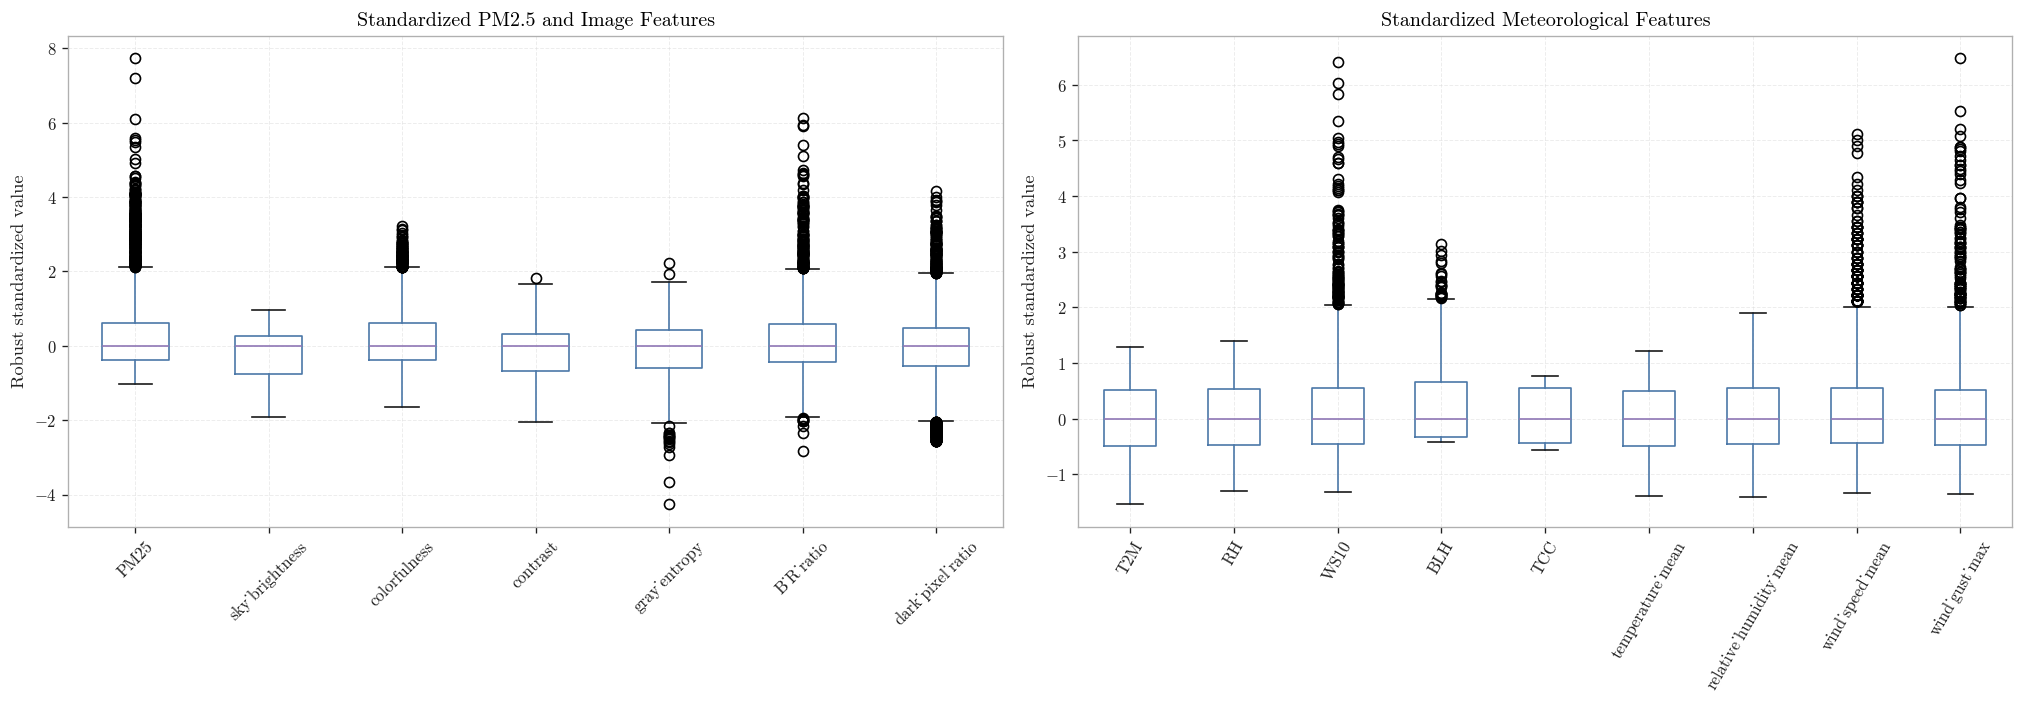

In [473]:
image_columns = [
    "PM25",
    "sky_brightness",
    "colorfulness",
    "contrast",
    "gray_entropy",
    "B_R_ratio",
    "dark_pixel_ratio",
]

weather_columns = [
    "T2M",
    "RH",
    "WS10",
    "BLH",
    "TCC",
    "temperature_mean",
    "relative_humidity_mean",
    "wind_speed_mean",
    "wind_gust_max",
]

def robust_scale(data):
    median = data.median()
    iqr = data.quantile(0.75) - data.quantile(0.25)
    return (data - median) / iqr.replace(0, np.nan)

image_scaled = robust_scale(df[image_columns])
weather_scaled = robust_scale(df[weather_columns])

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
image_scaled.boxplot(ax=axes[0], rot=45)
axes[0].set_title("Standardized PM2.5 and Image Features")
axes[0].set_ylabel("Robust standardized value")

weather_scaled.boxplot(ax=axes[1], rot=60)
axes[1].set_title("Standardized Meteorological Features")
axes[1].set_ylabel("Robust standardized value")

plt.tight_layout()
plt.show()

### 5.3 Monthly Sample Counts Before and After Cleaning

Compare monthly sample availability before and after cleaning to assess
how many observations were removed and whether cleaning disproportionately
affected specific periods.

In [474]:
# Monthly sample counts before cleaning
before_month = (
    pd.to_datetime(
        df_raw["time"],
        errors="coerce"
    )
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

# Monthly sample counts after cleaning
after_month = (
    df["time"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

# Combine results
monthly_counts = pd.concat(
    [
        before_month.rename("before_cleaning"),
        after_month.rename("after_cleaning"),
    ],
    axis=1
).fillna(0).astype(int)

monthly_counts["removed"] = (
    monthly_counts["before_cleaning"] -
    monthly_counts["after_cleaning"]
)

monthly_counts["retained_percent"] = (
    monthly_counts["after_cleaning"] /
    monthly_counts["before_cleaning"] * 100
).round(2)

display(monthly_counts)

,before_cleaning,after_cleaning,removed,retained_percent
time,,,,
2025-01,20,20,0,100.00
2025-02,86,86,0,100.00
2025-03,101,100,1,99.01
2025-04,99,99,0,100.00
2025-05,98,98,0,100.00
2025-06,59,46,13,77.97
2025-10,60,60,0,100.00
2026-03,600,528,72,88.00
2026-04,599,599,0,100.00


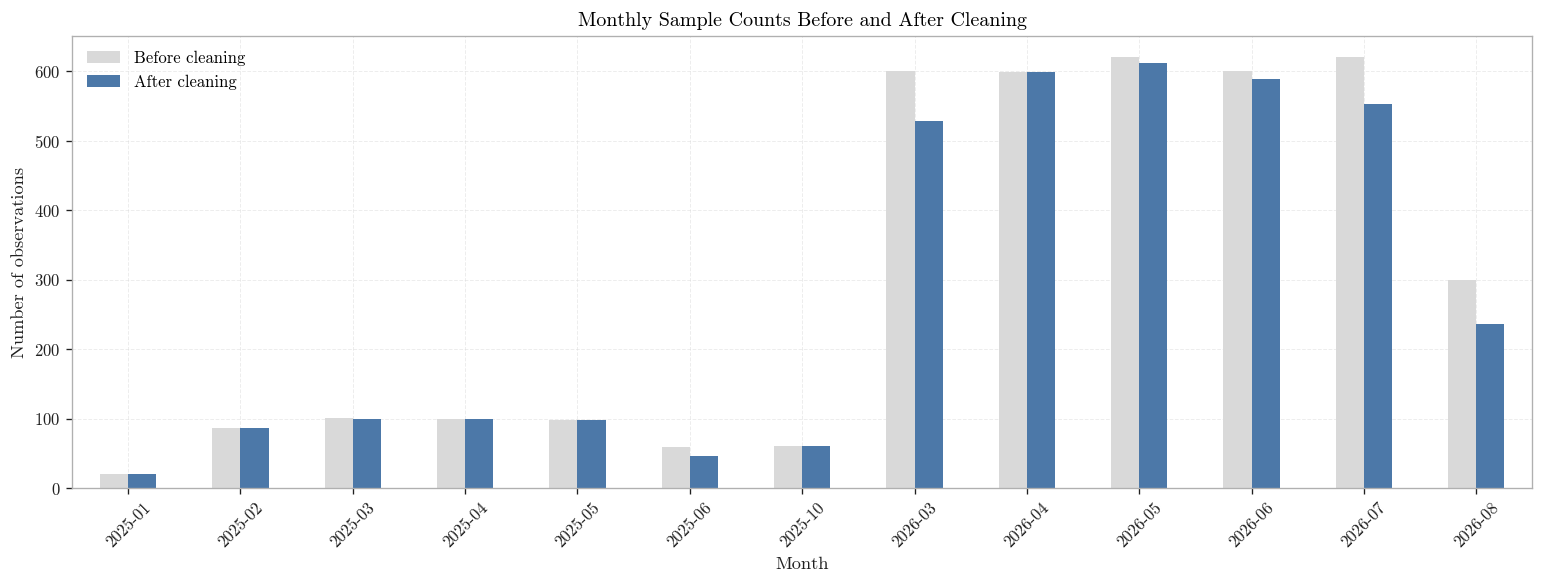

In [475]:
monthly_counts[
    [
        "before_cleaning",
        "after_cleaning",
    ]
].plot(
    kind="bar",
    figsize=(13, 5),
    color=[COLORS["grid"], COLORS["primary"]]
)

plt.xlabel("Month")
plt.ylabel("Number of observations")
plt.title("Monthly Sample Counts Before and After Cleaning")
plt.xticks(rotation=45)
plt.legend(
    ["Before cleaning", "After cleaning"]
)

plt.tight_layout()
plt.show()

## 6. Export & Summary

### 6.1 Export Cleaned Dataset

Export the final cleaned dataset for subsequent modeling and analysis.

In [476]:
OUTPUT_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "final_dataset.csv"
)

OUTPUT_FILE.parent.mkdir(
    parents=True,
    exist_ok=True
)

df.to_csv(
    OUTPUT_FILE,
    index=False,
    date_format="%Y-%m-%d %H:%M:%S"
)

print(
    "Final dataset exported to:",
    OUTPUT_FILE.relative_to(PROJECT_ROOT)
)

print("Exported shape:", df.shape)

Final dataset exported to: data/processed/final_dataset.csv
Exported shape: (3625, 57)


### 6.2 Final Summary

Summarize the final structure and quality of the cleaned dataset.

In [477]:
initial_rows = len(df_raw)
final_rows = len(df)
removed_rows = initial_rows - final_rows

removed_percent = (
    removed_rows / initial_rows * 100
)

print("Final Dataset Summary")

print("\nDataset size")
print("Initial rows:", initial_rows)
print("Final rows:", final_rows)
print("Rows removed:", removed_rows)
print(
    "Rows removed (%):",
    round(removed_percent, 2)
)
print("Final columns:", df.shape[1])

print("\nData quality")
print(
    "Remaining missing values:",
    df.isna().sum().sum()
)
print(
    "Duplicated timestamps:",
    df["time"].duplicated().sum()
)
print(
    "Infinite values:",
    np.isinf(
        df.select_dtypes(include=np.number)
    ).sum().sum()
)

print("\nTemporal coverage")
print("Start time (UTC):", df["time"].min())
print("End time (UTC):", df["time"].max())
print(
    "Months covered:",
    df["time"].dt.to_period("M").nunique()
)

print("\nOutput")
print(
    OUTPUT_FILE.relative_to(PROJECT_ROOT)
)

Final Dataset Summary

Dataset size
Initial rows: 3862
Final rows: 3625
Rows removed: 237
Rows removed (%): 6.14
Final columns: 57

Data quality
Remaining missing values: 0
Duplicated timestamps: 0
Infinite values: 0

Temporal coverage
Start time (UTC): 2025-01-29 15:00:00
End time (UTC): 2026-08-12 21:00:00
Months covered: 13

Output
data/processed/final_dataset.csv
